# Chapter 10: Interactions, Groups, and Text

**As more candidate pairs are screened, does the search score keep describing what the selected features earn on new rows?**

Every extra pair screened is another chance for noise to look like signal. The search score is computed on the rows that chose the pairs, so it can rise while the recipe gets worse on rows that did not.

*Constructed data; one interaction is real by design, and the sizes of the effects are properties of this generator. The noise cost is small per pair and shows only in the accumulation.*

## The experiment

A constructed binary task with 12 numeric features, three main effects and exactly one real interaction, x0 times x1. The chapter's accept rule (keep a pair if development AUC rises by more than 0.00001) runs over every pairwise product of the first k features, using a logistic regression and 5-fold cross-validation on 1,200 rows. The control is k. The selected recipe is then refitted on the same 1,200 rows and scored once on 20,000 fresh rows from the same generator, which stands in for a reserved assessment partition. Six independent datasets are averaged.

In [1]:
import itertools

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

from kaggle_companion.activities._common import clean

SEED = 10
REPLICATES = 6         # independent constructed datasets; every estimate is their mean
N_SEARCH = 1200        # rows the stepwise search may use
N_FRESH = 20000        # fresh rows from the same generator: the stand-in for a reserved assessment partition
MIN_GAIN = 1e-5        # the chapter's accept rule: keep a pair if the development AUC rises by more than this


def generate(n, rng):
    """Twelve numeric features. One real interaction, x0 * x1, on top of three main effects; the rest is noise."""
    X = rng.normal(size=(n, 12))
    logit = 0.8 * X[:, 0] + 0.5 * X[:, 1] + 0.4 * X[:, 2] + 1.0 * X[:, 0] * X[:, 1] - 0.2
    y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return X, y


def design(X, pairs):
    """Original columns plus one product column per kept pair."""
    return np.column_stack([X] + [X[:, a] * X[:, b] for a, b in pairs])


def cv_auc(X, y, folds):
    """Development score: mean AUC of a logistic regression over the search folds."""
    scores = []
    for fit, val in folds:
        model = LogisticRegression(max_iter=200).fit(X[fit], y[fit])
        scores.append(roc_auc_score(y[val], model.decision_function(X[val])))
    return float(np.mean(scores))


def stepwise_search(X, y, pairs, folds):
    """The chapter's accept rule: try each pair in turn, keep it if the development AUC rises by more than MIN_GAIN."""
    current = X
    base = cv_auc(current, y, folds)
    trace, kept = [base], []
    for a, b in pairs:
        trial = np.column_stack([current, X[:, a] * X[:, b]])
        score = cv_auc(trial, y, folds)
        if score - base > MIN_GAIN:
            base, current = score, trial
            kept.append((a, b))
            trace.append(score)
    return kept, trace


def fresh_auc(X, y, pairs, X_new, y_new):
    """Refit on the search rows with the given pairs, score once on rows the search never saw."""
    model = LogisticRegression(max_iter=200).fit(design(X, pairs), y)
    return roc_auc_score(y_new, model.decision_function(design(X_new, pairs)))


def run(top_features):
    pairs = list(itertools.combinations(range(top_features), 2))
    search_gain, fresh_gain, oracle_gain, noise, found = [], [], [], [], []
    for rep in range(REPLICATES):
        rng = np.random.default_rng(SEED * 100 + rep)
        X, y = generate(N_SEARCH + N_FRESH, rng)
        Xs, ys, Xf, yf = X[:N_SEARCH], y[:N_SEARCH], X[N_SEARCH:], y[N_SEARCH:]
        folds = list(StratifiedKFold(5, shuffle=True, random_state=42).split(Xs, ys))
        kept, trace = stepwise_search(Xs, ys, pairs, folds)
        base_fresh = fresh_auc(Xs, ys, [], Xf, yf)
        search_gain.append(trace[-1] - trace[0])
        fresh_gain.append(fresh_auc(Xs, ys, kept, Xf, yf) - base_fresh)
        oracle_gain.append(fresh_auc(Xs, ys, [(0, 1)], Xf, yf) - base_fresh)   # the one pair that is really there
        noise.append(len([p for p in kept if p != (0, 1)]))
        found.append((0, 1) in kept)
        if rep == 0:   # the path of the first dataset: development AUC and fresh AUC after each accepted pair
            path = [[i, trace[i], fresh_auc(Xs, ys, kept[:i], Xf, yf)] for i in range(len(kept) + 1)]
    return clean({
        "top_features": top_features, "pairs_screened": len(pairs),
        "search_gain": float(np.mean(search_gain)), "fresh_gain": float(np.mean(fresh_gain)),
        "oracle_gain": float(np.mean(oracle_gain)), "noise_pairs_kept": float(np.mean(noise)),
        "true_pair_found": float(np.mean(found)),
        "per_replicate": {"search_gain": search_gain, "fresh_gain": fresh_gain},
        "path": path, "replicates": REPLICATES, "search_rows": N_SEARCH, "fresh_rows": N_FRESH,
    })


## Measure it across the control

The control is **top features whose pairwise products are screened**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch10 import explain

VALUES = [4, 6, 9, 12]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                         4       6       9      12
Pairs screened           6      15      36      66
Search score gain   +0.060  +0.061  +0.064  +0.071
Gain on fresh rows  +0.058  +0.056  +0.052  +0.044
True pair only      +0.059  +0.059  +0.059  +0.059
Noise pairs kept       1.7     3.2     6.8    14.3


## Look at it

The figure shows the default setting, top features whose pairwise products are screened = 12.

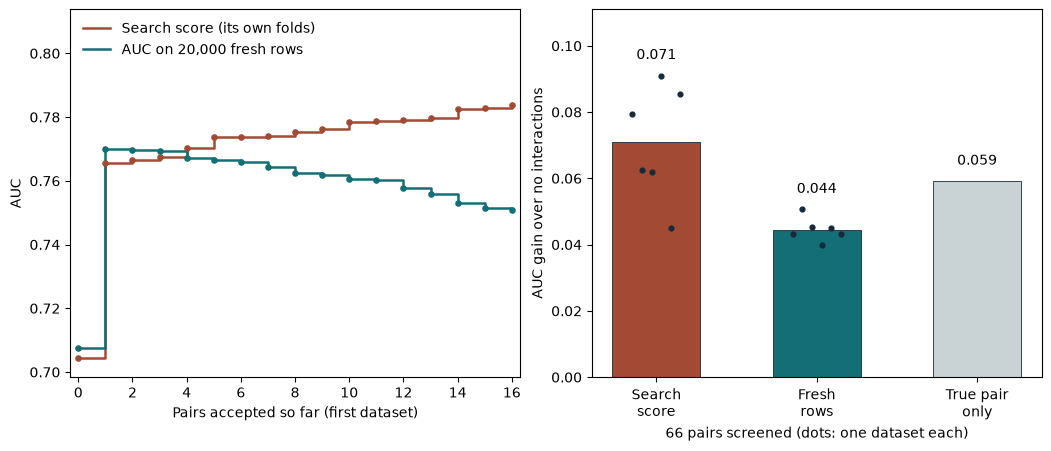

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch10 import draw, NCOLS, HEIGHT

DEFAULT = 12
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

Screening 66 pairs, the search reports a gain of 0.071 AUC and the same recipe earns 0.044 on fresh rows, so 0.071 - 0.044 = 0.027 of the reported gain is selection bias (standard error 0.008 over 6 datasets). It kept 14.3 pairs other than the true one on average and found the true pair in 100% of datasets. Adding only the true pair earns 0.059, so the noise pairs cost 0.015 on fresh rows.

- Search gain minus fresh gain: 0.071 - 0.044 = 0.027 AUC.
- Fresh gain minus true-pair-only gain: 0.044 - 0.059 = -0.015 AUC.
- Pairs screened: 66; pairs other than the true one kept: 14.3 on average.

## Apply this to your competition

- Reserve an assessment partition before the interaction search, or nest the entire search inside each outer training fold.
- Report the frozen recipe's gain on the reserved rows; the search's own final score is a development number.
- Keep the screen as small as the domain allows, and log how many pairs were screened and how many were kept.
- Add a minimum-gain margin that reflects fold-to-fold noise instead of accepting any positive gain.

Book location: Chapter 10, Interaction Features: The Stepwise Approach.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)